REGIONES Y FRONTERAS 

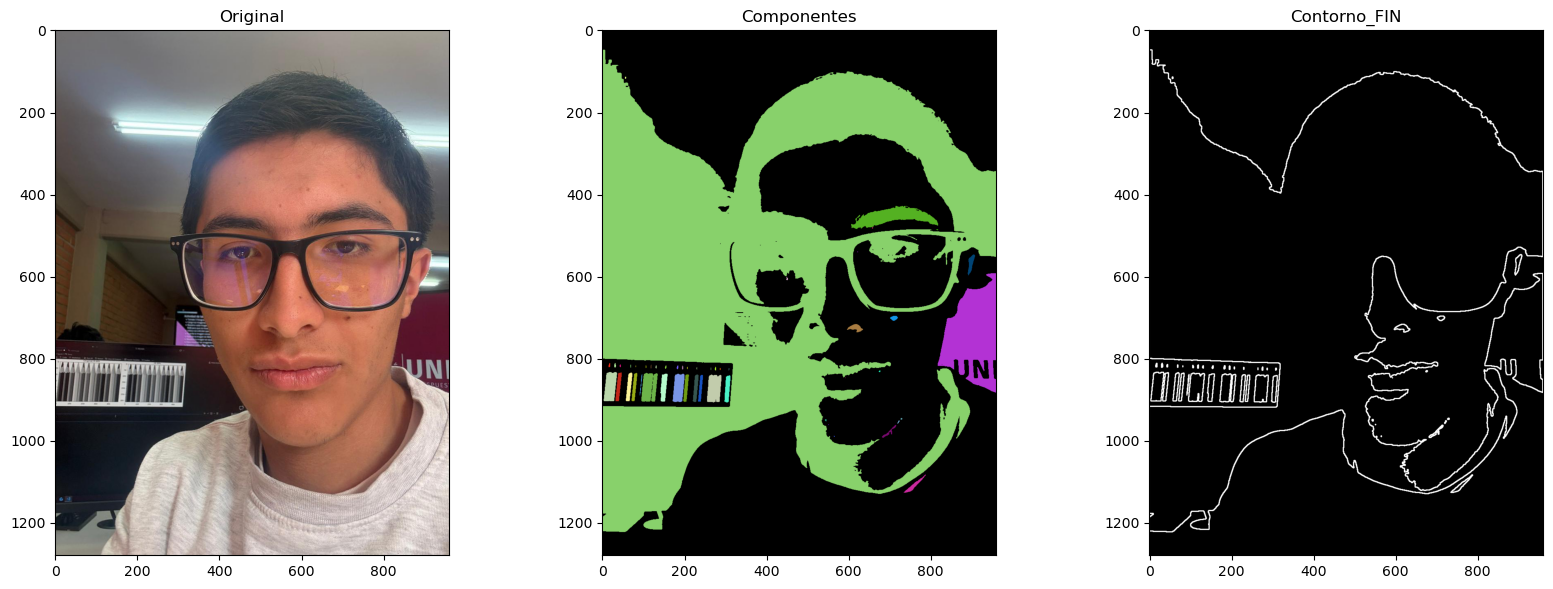

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('imagen1.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (7, 7), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
num_l, label = cv2.connectedComponents(binary)

color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)
color[0] = [0, 0, 0] 
colorear = color[label]
contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

plt.figure(figsize=(20, 15))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(2, 3, 2)
plt.imshow(colorear)
plt.title("Componentes")

plt.subplot(2, 3, 3)
plt.imshow(contorno_fin,cmap='gray')
plt.title("Contorno_FIN")

plt.show()

CONTEO

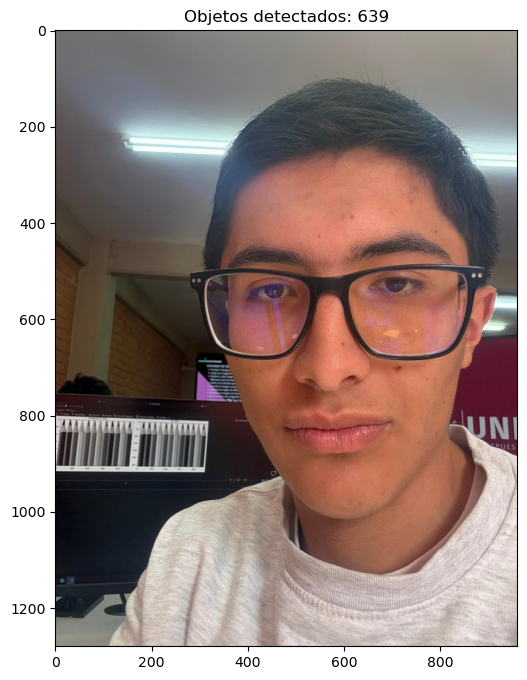

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    e_img = measure.label(binary, connectivity=2)  # conectividad 8
    num_obj = np.max(e_img)
    return num_obj

# Cargar imagen
imagen = cv2.imread('imagen1.jpg')

# Contar elementos
num = contar_elementos(imagen)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title(f"Objetos detectados: {num}")
plt.show()

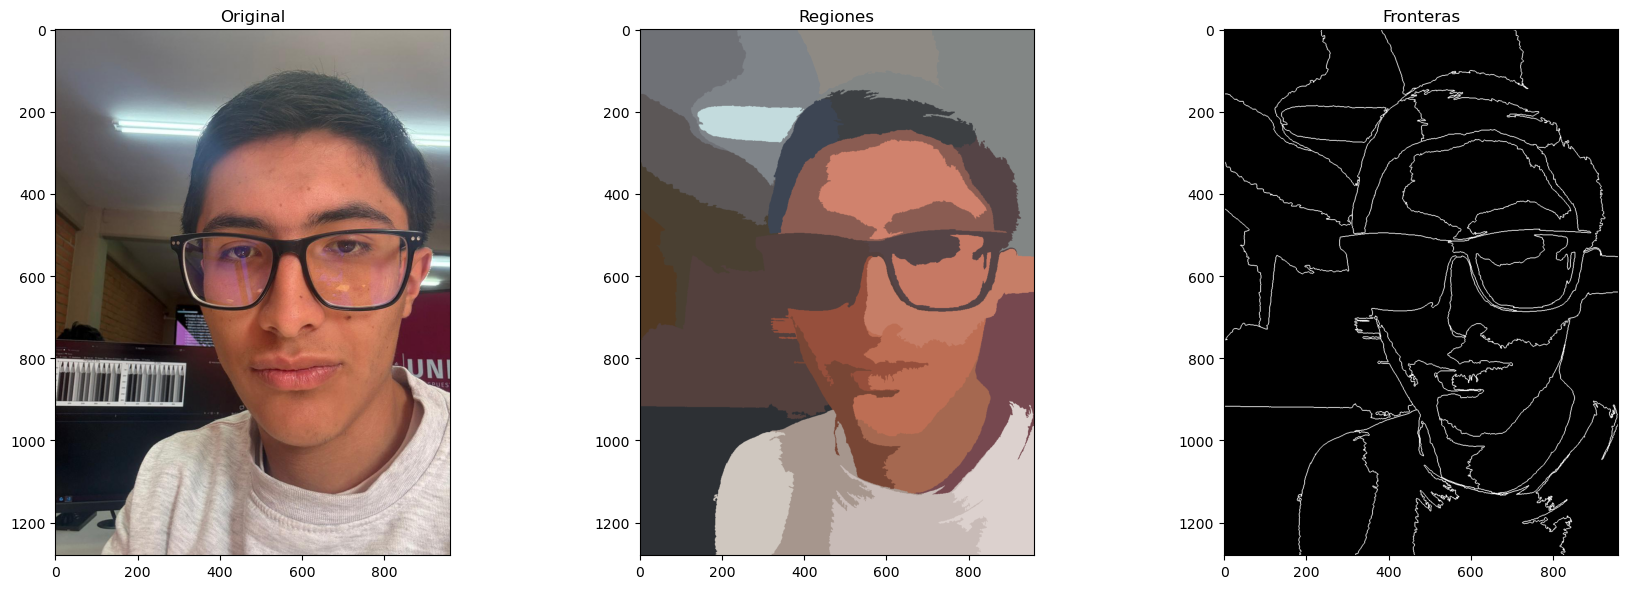

Total regiones 26

color 111, 113, 118 objetos 42973
color 127, 132, 137 objetos 48685
color 142, 138, 132 objetos 37420
color 130, 134, 133 objetos 89329
color 61, 64, 67 objetos 28486
color 92, 87, 87 objetos 49070
color 61, 69, 83 objetos 21810
color 195, 219, 221 objetos 17659
color 138, 92, 82 objetos 47212
color 85, 68, 70 objetos 41677
color 208, 130, 109 objetos 55119
color 74, 64, 50 objetos 47749
color 81, 57, 34 objetos 19587
color 83, 64, 61 objetos 153916
color 198, 121, 100 objetos 25440
color 198, 126, 103 objetos 38463
color 150, 79, 60 objetos 31876
color 118, 72, 79 objetos 44351
color 120, 70, 53 objetos 25526
color 189, 110, 84 objetos 47686
color 165, 104, 80 objetos 39875
color 220, 209, 206 objetos 47217
color 45, 48, 52 objetos 83302
color 166, 150, 141 objetos 48511
color 207, 199, 191 objetos 44723
color 200, 187, 183 objetos 51138


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.segmentation import slic, find_boundaries
from skimage.color import label2rgb
from skimage.util import img_as_float

img = cv2.imread("imagen1.jpg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_float = img_as_float(img_rgb)

segmentos = slic(
    img_float,
    n_segments=34,
    compactness=10,
    sigma=1,
    start_label=1
)

regiones = label2rgb(
    segmentos,
    image=img_float,
    kind="avg"
)

fronteras = find_boundaries(
    segmentos,
    mode="thick"
)

img_fronteras = np.zeros_like(img_rgb)
img_fronteras[fronteras] = [255, 255, 255]

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("on")

plt.subplot(1, 3, 2)
plt.imshow(regiones)
plt.title("Regiones")
plt.axis("on")

plt.subplot(1, 3, 3)
plt.imshow(img_fronteras)
plt.title("Fronteras")
plt.axis("on")

plt.tight_layout()
plt.show()

valores, conteos = np.unique(segmentos, return_counts=True)

print("Total regiones", len(valores))
print()

for region, cantidad in zip(valores, conteos):
    mascara = segmentos == region
    color_promedio = img_rgb[mascara].mean(axis=0)
    r, g, b = color_promedio.astype(int)

    print(f"color {r}, {g}, {b} objetos {cantidad}")